# Realce no Domínio do Espaço e Filtros Espaciais

In [1]:
# Download do OpenCV
!pip install opencv-python

In [2]:
# Importação das bibliotecas
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [3]:
# Download do repositório
if os.path.isdir("pdsi"):
  print("Diretório já existe!")
else:
  !git clone https://github.com/NaldoHoracio/pdsi

Cloning into 'pdsi'...
remote: Enumerating objects: 204, done.
remote: Total 204 (delta 0), reused 0 (delta 0), pack-reused 204 (from 1)
Receiving objects: 100% (204/204), 86.01 MiB | 24.02 MiB/s, done.
Resolving deltas: 100% (37/37), done.


# Transformações Básicas em Nível de Cinza

## Negativo de uma imagem

In [4]:
def negative(x):
    L=256
    return ((L - 1) - x)

In [5]:
path0 = 'pdsi/imagens/mammography.jpg'

img0 = cv2.imread(path0, cv2.IMREAD_GRAYSCALE)
img0.shape

(628, 529)

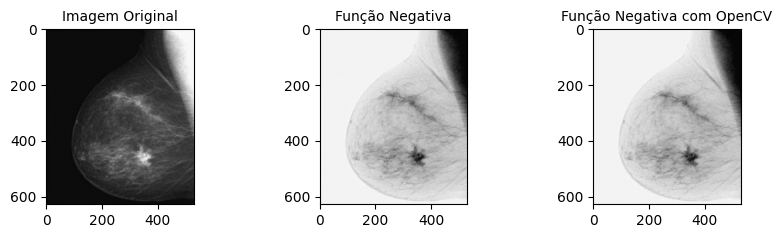

In [6]:
img0_negative = negative(img0)
img0_negative_cv = cv2.bitwise_not(img0)

plt.figure(figsize=(10,5))

plt.subplot(231);plt.title('Imagem Original', fontsize=10);plt.imshow(img0, cmap='gray')
plt.subplot(232);plt.title('Função Negativa', fontsize=10);plt.imshow(img0_negative, cmap='gray')
plt.subplot(233);plt.title('Função Negativa com OpenCV', fontsize=10);plt.imshow(img0_negative_cv, cmap='gray')

## Log de uma imagem

A fórmula para aplicar a transformação de log em uma imagem é,

s = c * log (1 + r)

onde,

r = input pixel value,
c = scaling constant and
s = output pixel value

O valor de 'c' é escolhido de forma que obtenhamos o valor máximo de saída correspondente ao tamanho de bit usado. Assim, a fórmula para calcular 'c' é a seguinte:

c = 255 / (log (1 + max_input_pixel_value)

In [7]:
# Read an image
img1 = cv2.imread('pdsi/imagens/grayView.jpg')
img1.shape

(500, 500, 3)

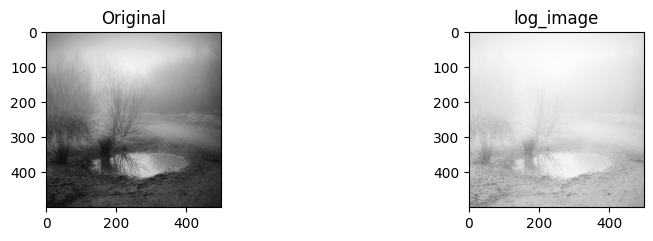

In [8]:
# Apply log transformation method
c = 255 / np.log(1 + np.max(img1))
log_image = c * (np.log(img1 + 1))

# Specify the data type so that
# float value will be converted to int
log_image = np.array(log_image, dtype = np.uint8)

# Display both images
plt.figure(figsize=(10, 5))
plt.subplot(2, 2, 1)
plt.title('Original')
plt.imshow(img1)


plt.subplot(2, 2, 2)
plt.title('log_image')
plt.imshow(log_image)

plt.show()

## Gamma

In [9]:
def gamma(x, gamma):
    lookUpTable = np.empty((1,256), np.uint8)
    for i in range(256):
        lookUpTable[0,i] = np.clip(pow(i / 255.0, gamma) * 255.0, 0, 255)
    y = cv2.LUT(x, lookUpTable)
    return y

In [10]:
path2 = 'pdsi/imagens/white-black-gradient.jpg'
img2 = cv2.imread(path2)
img2.shape

(360, 360, 3)

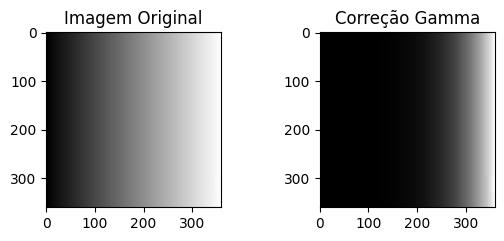

In [11]:
# Escolha do parâmetro gama
gamma_param = 5.0
gamma_result = gamma(img2, gamma_param)

plt.figure(figsize=(10,5))
plt.subplot(231);plt.title('Imagem Original');plt.imshow(img2)
plt.subplot(232);plt.title('Correção Gamma');plt.imshow(gamma_result)

In [15]:
path3 = './pdsi/imagens/mri.jpg'
img3 = cv2.imread(path3)
img3.shape

(867, 662, 3)

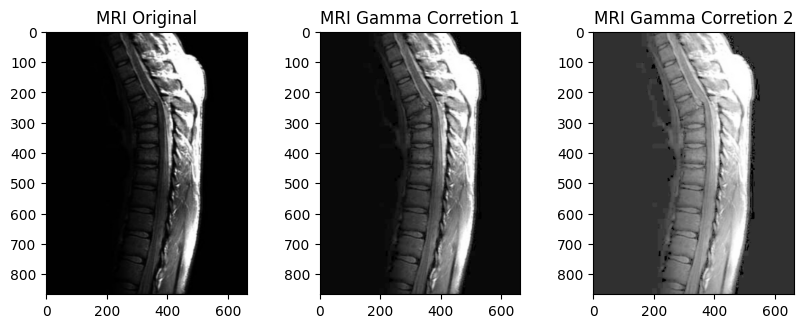

In [18]:
gamma_param = 0.6
MRI_img = cv2.imread(path3)
MRI_result = gamma(img3, gamma_param)
gamma_param = 0.3
MRI_result2 = gamma(img3, gamma_param)

plt.figure(figsize=(10, 7.5))
plt.subplot(231);plt.title('MRI Original');plt.imshow(img3)
plt.subplot(232);plt.title('MRI Gamma Corretion 1');plt.imshow(MRI_result)
plt.subplot(233);plt.title('MRI Gamma Corretion 2');plt.imshow(MRI_result2)

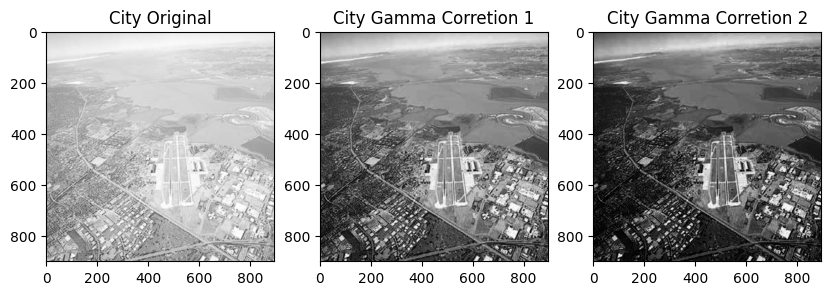

In [19]:
path4 = './pdsi/imagens/city.jpg'
gamma_param = 3.0
img4 = cv2.imread(path4)
city_result = gamma(img4, gamma_param)
gamma_param = 5.0
city_result2 = gamma(img4, gamma_param)

plt.figure(figsize=(10, 7.5))
plt.subplot(231);plt.title('City Original');plt.imshow(img4)
plt.subplot(232);plt.title('City Gamma Corretion 1');plt.imshow(city_result)
plt.subplot(233);plt.title('City Gamma Corretion 2');plt.imshow(city_result2)

## Histograma

In [22]:
p1_path = './pdsi/imagens/pollen1.jpg'
p2_path = './pdsi/imagens/pollen2.jpg'
p3_path = './pdsi/imagens/pollen3.jpg'
p4_path = './pdsi/imagens/pollen4.jpg'

p1_img = cv2.imread(p1_path)
p2_img = cv2.imread(p2_path)
p3_img = cv2.imread(p3_path)
p4_img = cv2.imread(p4_path)

print(f"Shape img1: {p1_img.shape}\nShape img2: {p2_img.shape}\nShape img3: {p3_img.shape}\nShape img4: {p4_img.shape}")

Shape img1: (795, 795, 3)
Shape img2: (795, 795, 3)
Shape img3: (795, 795, 3)
Shape img4: (795, 795, 3)


/tmp/ipykernel_1011/972478044.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(232);plt.hist(np.ravel(p1_img),256,[0,256]); plt.show()


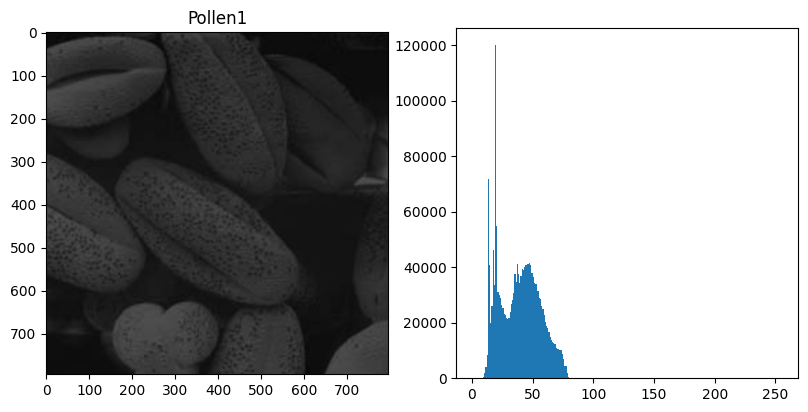

In [24]:
# Compute histogram using cv
pollen1_hist = cv2.calcHist([p1_img],[0],None,[256],[0,256])

# Ploting with matplot
plt.figure(figsize=(15, 10))
plt.subplot(231);plt.title('Pollen1');plt.imshow(p1_img)
plt.subplot(232);plt.hist(np.ravel(p1_img),256,[0,256]); plt.show()

/tmp/ipykernel_1011/1164108629.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(232);plt.hist(np.ravel(p2_img),256,[0,256]); plt.show()


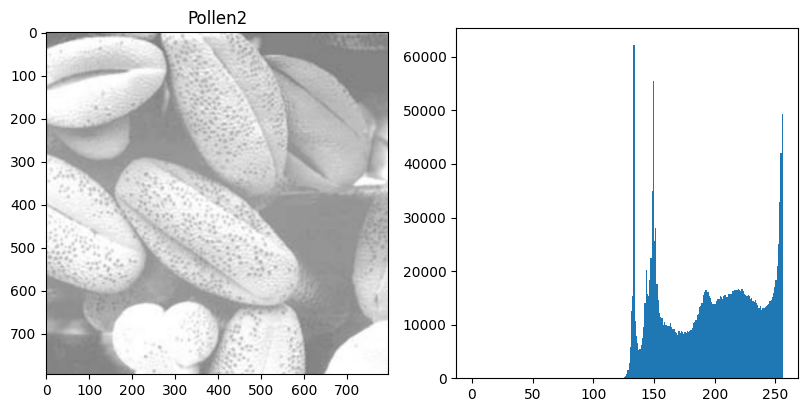

In [25]:
# Compute histogram using cv
p2_hist = cv2.calcHist([p2_img],[0],None,[256],[0,256])

# Ploting with matplot
plt.figure(figsize=(15,10))
plt.subplot(231);plt.title('Pollen2');plt.imshow(p2_img)
plt.subplot(232);plt.hist(np.ravel(p2_img),256,[0,256]); plt.show()

/tmp/ipykernel_1011/2152889366.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(232);plt.hist(np.ravel(p3_img),256,[0,256]); plt.show()


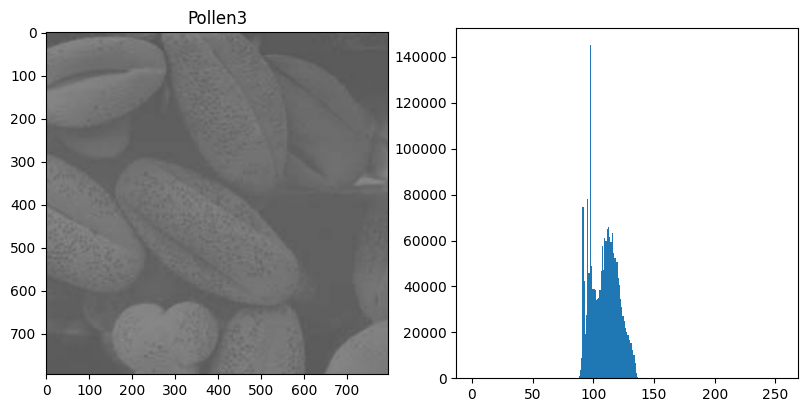

In [26]:
# Compute histogram using cv
p3_hist = cv2.calcHist([p3_img],[0],None,[256],[0,256])

# Ploting with matplot
plt.figure(figsize=(15,10))
plt.subplot(231);plt.title('Pollen3');plt.imshow(p3_img)
plt.subplot(232);plt.hist(np.ravel(p3_img),256,[0,256]); plt.show()

/tmp/ipykernel_1011/4003419231.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(232);plt.hist(np.ravel(p4_img),256,[0,256]); plt.show()


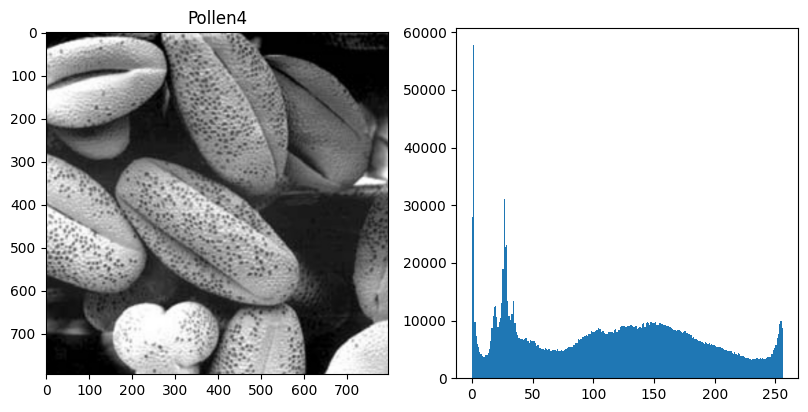

In [27]:
# Compute histogram using cv
p4_hist = cv2.calcHist([p4_img],[0],None,[256],[0,256])

# Ploting with matplot
plt.figure(figsize=(15,10))
plt.subplot(231);plt.title('Pollen4');plt.imshow(p4_img)
plt.subplot(232);plt.hist(np.ravel(p4_img),256,[0,256]); plt.show()

# Filtros Espaciais

## Filtro passa-baixa

In [29]:
### References ###
# https://medium.com/@aybukeyalcinerr/correlation-vs-convolution-filtering-2711d8bb3666
# https://www.pyimagesearch.com/2016/07/25/convolutions-with-opencv-and-python/
# https://docs.opencv.org/3.4/dd/d6a/tutorial_js_filtering.html
# https://opencv-python-tutroals.readthedocs.io/en/latest/py_tutorials/py_imgproc/py_filtering/py_filtering.html

def box_filter(img, kernel_size):
    kernel = 1/(kernel_size**2)*np.ones((kernel_size,kernel_size))
    dst = cv2.filter2D(img, -1, kernel)
    return dst

In [30]:
path5 = './pdsi/imagens/artificial.jpg'
img5 = cv2.imread(path5)
img5.shape

(687, 684, 3)

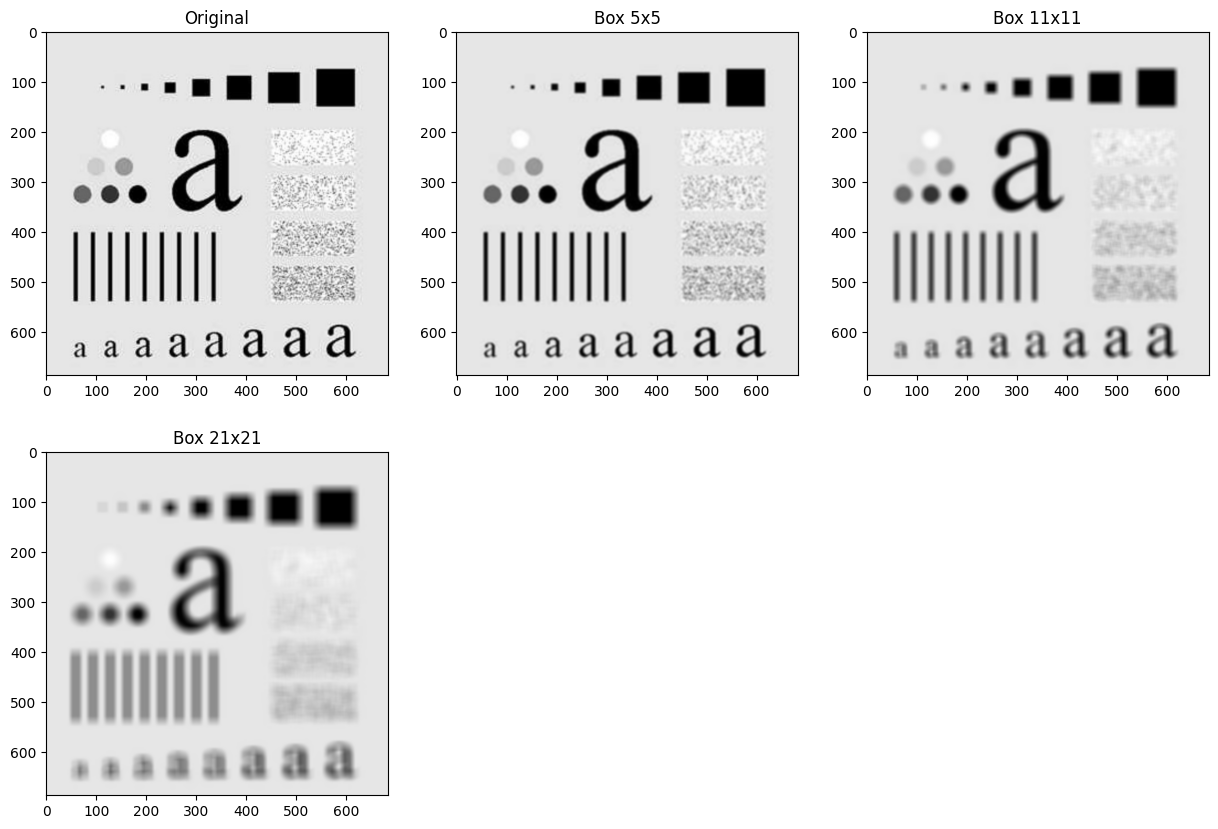

In [31]:
img5_box5_filtered = box_filter(img5, 5)
img5_box11_filtered = box_filter(img5, 11)
img5_box21_filtered = box_filter(img5,21)

plt.figure(figsize=(15,10))
plt.subplot(231);plt.title('Original');plt.imshow(img5)
plt.subplot(232);plt.title('Box 5x5');plt.imshow(img5_box5_filtered)
plt.subplot(233);plt.title('Box 11x11');plt.imshow(img5_box11_filtered)
plt.subplot(234);plt.title('Box 21x21');plt.imshow(img5_box21_filtered)

## Filtro gaussiano passa-baixa

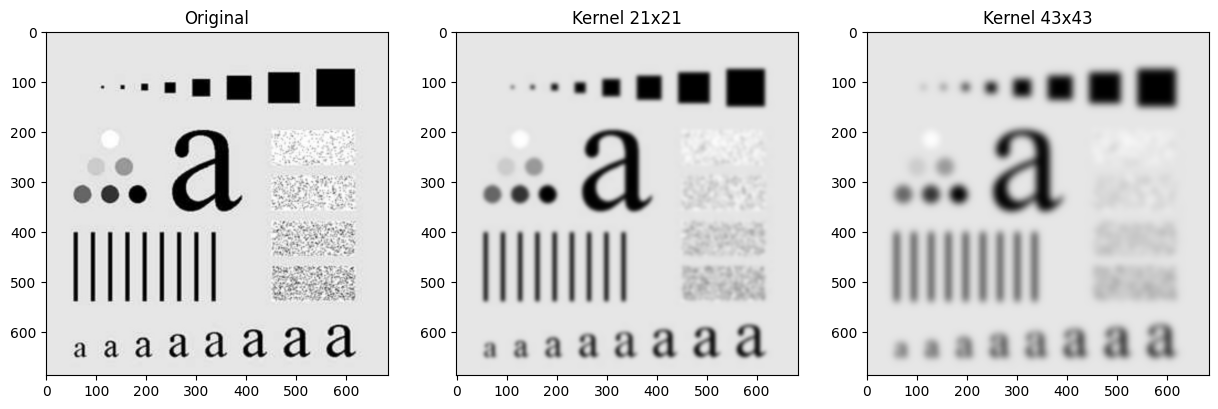

In [32]:
img5_gauss21_filtered = cv2.GaussianBlur(img5,(21,21), 0)
img5_gauss43_filtered = cv2.GaussianBlur(img5,(43,43), 0)

plt.figure(figsize=(15,10))
plt.subplot(231);plt.title('Original');plt.imshow(img5)
plt.subplot(232);plt.title('Kernel 21x21');plt.imshow(img5_gauss21_filtered)
plt.subplot(233);plt.title('Kernel 43x43');plt.imshow(img5_gauss43_filtered)

## Filtro passa-alta (sharpening)

In [37]:
laplacian_kernelA0 = np.array([[0, -1, 0],[-1, 4, -1],[0, -1, 0]]) # Using c = +1
laplacian_kernelA1 = np.array([[0, 1, 0],[1, -4, 1],[0, 1, 0]]) # Using c = -1

moon_path = './pdsi/imagens/moon.jpg'
moon_img = cv2.imread(moon_path)
moon_img.shape

(415, 359, 3)

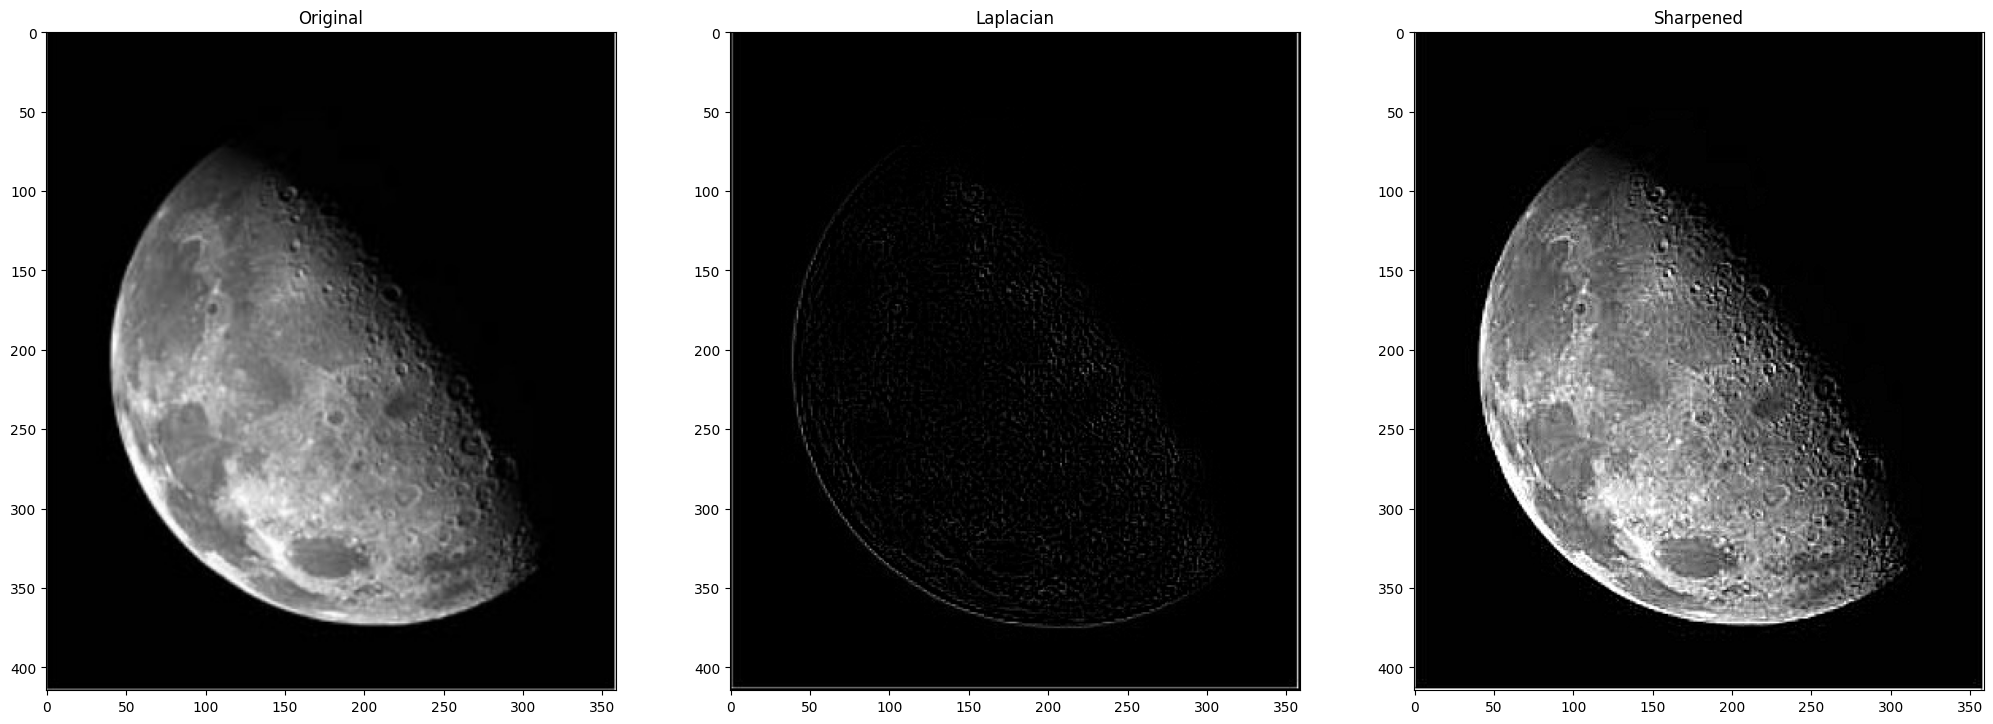

In [38]:
moon_laplacianA0 = cv2.filter2D(moon_img, cv2.CV_16S, laplacian_kernelA0) # Using c = +1
moon_laplacianA1 = cv2.filter2D(moon_img, cv2.CV_16S, laplacian_kernelA1) # Using c = -1

c = -1
sharp = moon_img + c * moon_laplacianA1


plt.figure(figsize=(25,30))
plt.subplot(231);plt.title('Original');plt.imshow(moon_img)
# plt.subplot(232);plt.title('Laplacian');plt.imshow(moon_laplacianA0)
plt.subplot(232);plt.title('Laplacian');plt.imshow(moon_laplacianA1)
plt.subplot(233);plt.title('Sharpened');plt.imshow(sharp)

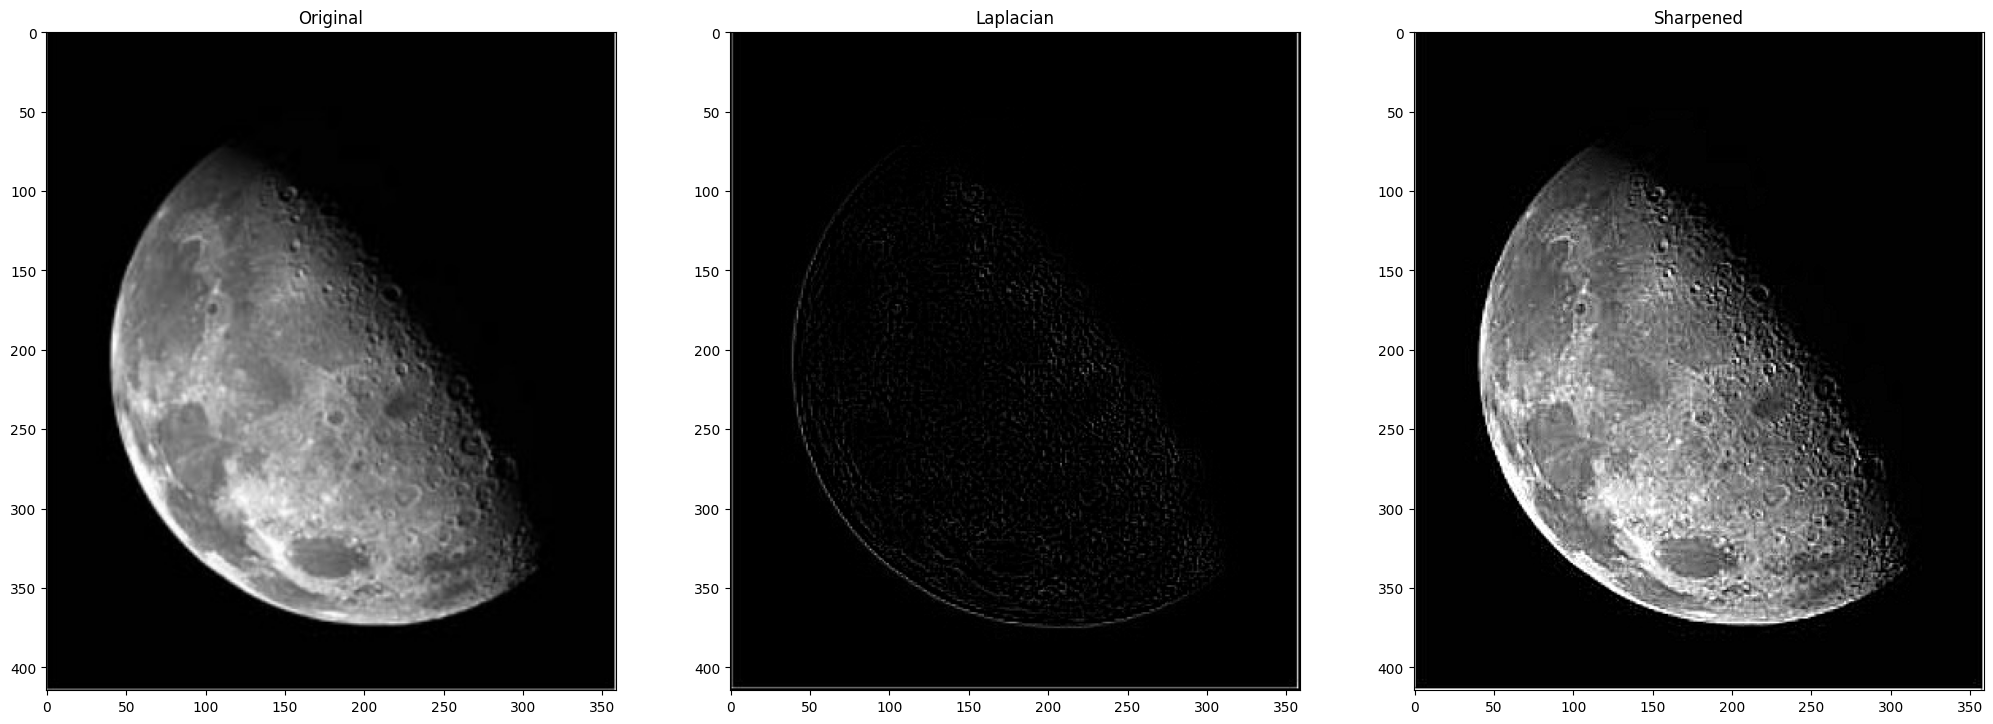

In [39]:
# Usando a função Laplacian da OpenCV
moon_laplacianB0 = cv2.Laplacian(moon_img, cv2.CV_16S, ksize=1)


# Using c = -1
c = - 1
sharp = moon_img + c * moon_laplacianB0

plt.figure(figsize=(25,30))
plt.subplot(231);plt.title('Original');plt.imshow(moon_img)
plt.subplot(232);plt.title('Laplacian');plt.imshow(moon_laplacianB0)
plt.subplot(233);plt.title('Sharpened');plt.imshow(sharp)